# FinBERT ECB v14 — Full Fix Edition
### Bugs fixed
| # | Bug | Fix |
|---|-----|-----|
| 1 | `F.cross_entropy` ignores class weights | `criterion` (with weights) used in every step |
| 2 | Duplicate `criterion` definitions | Single definition via `compute_class_weight` |
| 3 | `chunk_weight` commented-out / misused | Defined once, applied in loss correctly |
| 4 | Static predictions (majority-class collapse) | Class-weighted loss prevents collapse |
| 5 | Chunk-level ≡ speech-level (single chunk) | `MultiChunkDataset` → many chunks per speech |

### New additions
- `MultiChunkDataset` — overlapping 512-token chunks per speech
- **Gated LM + text fusion** — element-wise gating replaces plain concat
- **Proper AMP training loop** — autocast + GradScaler + gradient clipping
- **Speech-level evaluation** — logit aggregation across all chunks of a speech


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, gc, re, random, warnings
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
warnings.filterwarnings('ignore')

In [6]:
import torch, psutil

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM total : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"   VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")
else:
    print("⚠️  No GPU — Runtime → Change runtime type → T4 GPU")

ram = psutil.virtual_memory()
print(f"\n💾 RAM total    : {ram.total/1e9:.1f} GB")
print(f"   RAM available: {ram.available/1e9:.1f} GB")

✅ GPU: Tesla T4
   VRAM total : 15.6 GB
   VRAM free  : 15.6 GB

💾 RAM total    : 13.6 GB
   RAM available: 10.0 GB


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr
from torch.amp import autocast, GradScaler

import transformers
transformers.logging.set_verbosity_error()

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE = 'cuda' if device.type == 'cuda' else 'cpu'
AMP_DTYPE  = torch.float16 if device.type == 'cuda' else torch.float32

print(f"Device   : {device}")
print(f"AMP dtype: {AMP_DTYPE}")

Device   : cuda
AMP dtype: torch.float16


In [8]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [9]:
url = ("https://data-api.ecb.europa.eu/service/data/YC/"
       "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y"
       "?format=csvdata&startPeriod=1999-01-01")
r = requests.get(url)

lines = r.text.splitlines()
for i, line in enumerate(lines):
    if "TIME_PERIOD" in line:
        header = i
        break

bond = pd.read_csv(StringIO(r.text), skiprows=header)
bond = bond[['TIME_PERIOD', 'OBS_VALUE']]
bond.columns = ['date', 'Bond_Yield']
bond['date']       = pd.to_datetime(bond['date'])
bond['Bond_Yield'] = pd.to_numeric(bond['Bond_Yield'], errors='coerce')
bond = bond.dropna().sort_values('date')
print(f"Bond rows: {len(bond):,}  |  {bond['date'].min().date()} → {bond['date'].max().date()}")
bond.head()

Bond rows: 5,632  |  2004-09-06 → 2026-09-16


,date,Bond_Yield
0,2004-09-06,4.209220
1,2004-09-07,4.209626
2,2004-09-08,4.228419
3,2004-09-09,4.161872
4,2004-09-10,4.120981


In [10]:
speeches = pd.read_csv('/content/drive/MyDrive/ECB/all_ECB_speeches (1).csv', sep='|')
speeches['date'] = pd.to_datetime(speeches['date'], errors='coerce')
speeches = speeches.dropna(subset=['date'])
speeches['contents'] = speeches['contents'].astype(str).fillna('')

speeches_daily = speeches.groupby('date')['contents'].apply(' '.join).reset_index()
print(f"Daily speeches: {len(speeches_daily):,}")
speeches_daily.head()

Daily speeches: 2,319


,date,contents
0,1997-02-07,Conference organised by the Hungarian Bankin...
1,1997-03-10,Securing the benefits of EMU Address by Al...
2,1997-04-22,Convergence and the role of the European Cen...
3,1997-04-30,The operation of monetary policy in stage th...
4,1997-05-13,The European Central Bank: independent and a...


In [11]:
bond['yield_change'] = bond['Bond_Yield'].diff()

df = pd.merge_asof(
    speeches_daily.sort_values('date'),
    bond.sort_values('date'),
    on='date',
    direction='backward',
    tolerance=pd.Timedelta('7D')
).sort_values('date').reset_index(drop=True)

df['yield_change'] = df['Bond_Yield'].diff()
df['volatility']   = df['Bond_Yield'].rolling(5).std()
df['delta_same']   = df['Bond_Yield'].diff(periods=2)
df['delta_next']   = df['Bond_Yield'].shift(-2) - df['Bond_Yield']

upper_thr = df['delta_next'].quantile(0.65)
lower_thr = df['delta_next'].quantile(0.35)

def label(x):
    if x > upper_thr:  return 'UP'
    if x < lower_thr:  return 'DOWN'
    return 'NEUTRAL'

label_map = {'DOWN': 0, 'NEUTRAL': 1, 'UP': 2}
df['label_same'] = df['delta_same'].apply(label).map(label_map)
df['label_next'] = df['delta_next'].apply(label).map(label_map)
df = df.dropna(subset=['label_next']).reset_index(drop=True)

print("Labels distribution:")
print(df['label_next'].value_counts())

Labels distribution:
label_next
1    995
0    662
2    662
Name: count, dtype: int64


In [12]:
print(df.columns)

Index(['date', 'contents', 'Bond_Yield', 'yield_change', 'volatility',
       'delta_same', 'delta_next', 'label_same', 'label_next'],
      dtype='object')


In [13]:
LM_DICT_PATH = "/content/drive/MyDrive/ECB/Loughran-McDonald_MasterDictionary_1993-2024.csv"
lm_df = pd.read_csv(LM_DICT_PATH,
                    usecols=['Word','Negative','Positive',
                             'Uncertainty','Strong_Modal','Weak_Modal'])

lm_negative    = set(lm_df[lm_df['Negative']    > 0]['Word'].str.upper())
lm_positive    = set(lm_df[lm_df['Positive']    > 0]['Word'].str.upper())
lm_uncertainty = set(lm_df[lm_df['Uncertainty'] > 0]['Word'].str.upper())
lm_strong_modal= set(lm_df[lm_df['Strong_Modal']> 0]['Word'].str.upper())
lm_weak_modal  = set(lm_df[lm_df['Weak_Modal']  > 0]['Word'].str.upper())
del lm_df; gc.collect()

def compute_lm_features(text):
    words = re.findall(r'[A-Z]+', text.upper())
    n = max(len(words), 1)
    neg  = sum(1 for w in words if w in lm_negative)    / n * 100
    pos  = sum(1 for w in words if w in lm_positive)    / n * 100
    unc  = sum(1 for w in words if w in lm_uncertainty) / n * 100
    strn = sum(1 for w in words if w in lm_strong_modal)/ n * 100
    weak = sum(1 for w in words if w in lm_weak_modal)  / n * 100
    return {
        'lm_negative':       neg,
        'lm_positive':       pos,
        'lm_uncertainty':    unc,
        'lm_net_sentiment':  pos - neg,
        'lm_modal_certainty':strn - weak,
    }

lm_feat_df = pd.DataFrame(df['contents'].astype(str).apply(compute_lm_features).tolist())
df = pd.concat([df, lm_feat_df], axis=1)
print("✅ LM features computed")
print(df[['lm_negative','lm_positive','lm_uncertainty',
          'lm_net_sentiment','lm_modal_certainty']].describe().round(4))

✅ LM features computed
       lm_negative  lm_positive  lm_uncertainty  lm_net_sentiment  \
count    2319.0000    2319.0000       2319.0000         2319.0000   
mean        1.7281       1.3203          1.0663           -0.4078   
std         0.9532       0.6714          0.6500            1.0016   
min         0.0000       0.0000          0.0000           -4.4590   
25%         1.1277       0.9382          0.6805           -1.0518   
50%         1.6956       1.3321          1.0180           -0.3288   
75%         2.3473       1.7343          1.3909            0.2246   
max         5.2470       4.0936          4.5175            2.9126   

       lm_modal_certainty  
count           2319.0000  
mean               0.1063  
std                0.4343  
min               -1.8495  
25%               -0.1221  
50%                0.0378  
75%                0.3008  
max                2.9412  


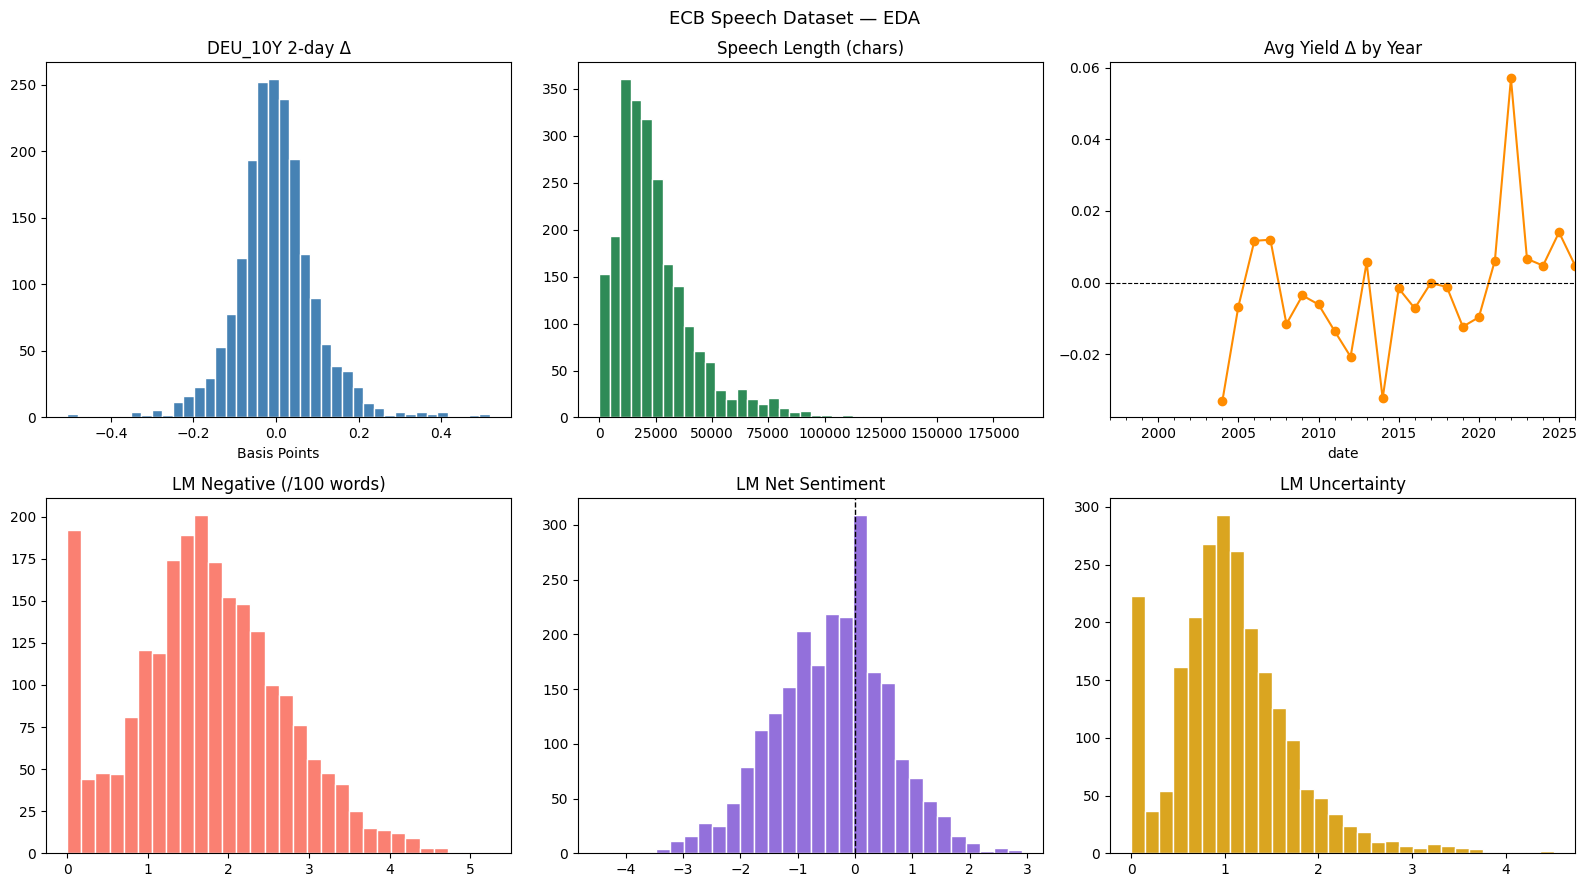

Avg speech: 24504 chars ≈ 5445 tokens
Date range: 1997-02-07 → 2026-06-01


In [14]:
df['text_len'] = df['contents'].astype(str).str.len()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(df['delta_same'].dropna(), bins=40, color='steelblue',  edgecolor='white')
axes[0,0].set_title('DEU_10Y 2-day Δ'); axes[0,0].set_xlabel('Basis Points')

axes[0,1].hist(df['text_len'].dropna(),  bins=40, color='seagreen',   edgecolor='white')
axes[0,1].set_title('Speech Length (chars)')

df.set_index('date')['delta_same'].resample('Y').mean().plot(
    ax=axes[0,2], marker='o', color='darkorange')
axes[0,2].axhline(0, color='black', lw=0.8, ls='--')
axes[0,2].set_title('Avg Yield Δ by Year')

axes[1,0].hist(df['lm_negative'],      bins=30, color='salmon',       edgecolor='white')
axes[1,0].set_title('LM Negative (/100 words)')

axes[1,1].hist(df['lm_net_sentiment'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(0, color='black', lw=1, ls='--'); axes[1,1].set_title('LM Net Sentiment')

axes[1,2].hist(df['lm_uncertainty'],   bins=30, color='goldenrod',    edgecolor='white')
axes[1,2].set_title('LM Uncertainty')

plt.suptitle('ECB Speech Dataset — EDA', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Avg speech: {df['text_len'].mean():.0f} chars ≈ {df['text_len'].mean()/4.5:.0f} tokens")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

labels = df['label_next'].values.astype(int)
texts  = df['contents'].astype(str).values

# Step 1: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    np.arange(len(df)), test_size=0.30,
    stratify=labels, random_state=42)

# Step 2: 30% → 15% val + 15% test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=labels[temp_idx], random_state=42)

# Text + labels
train_texts  = texts[train_idx]
val_texts    = texts[val_idx]
test_texts   = texts[test_idx]
train_labels = labels[train_idx]
val_labels   = labels[val_idx]
test_labels  = labels[test_idx]

# Temporal features
TEMPORAL_COLS = ['yield_change','volatility','Bond_Yield']
df[TEMPORAL_COLS] = df[TEMPORAL_COLS].fillna(0) # Ensure fillna before scaling

# Define and fit temporal_scaler using training data
train_temporal_for_scaler = df.iloc[train_idx][TEMPORAL_COLS].values.astype(np.float32)
temporal_scaler = StandardScaler().fit(train_temporal_for_scaler)

# Transform temporal features for all splits
train_temporal = temporal_scaler.transform(df.iloc[train_idx][TEMPORAL_COLS]).astype(np.float32)
val_temporal   = temporal_scaler.transform(df.iloc[val_idx][TEMPORAL_COLS]).astype(np.float32)
test_temporal  = temporal_scaler.transform(df.iloc[test_idx][TEMPORAL_COLS]).astype(np.float32)

# LM features
LM_FEATURE_COLS = ['lm_negative','lm_positive','lm_uncertainty',
                   'lm_net_sentiment','lm_modal_certainty']

# Define and fit lm_scaler using training data
train_lm_for_scaler = df.iloc[train_idx][LM_FEATURE_COLS].values.astype(np.float32)
lm_scaler = StandardScaler().fit(train_lm_for_scaler)

# Transform LM features for all splits
train_lm_feats = lm_scaler.transform(df.iloc[train_idx][LM_FEATURE_COLS]).astype(np.float32)
val_lm_feats   = lm_scaler.transform(df.iloc[val_idx][LM_FEATURE_COLS]).astype(np.float32)
test_lm_feats  = lm_scaler.transform(df.iloc[test_idx][LM_FEATURE_COLS]).astype(np.float32)


print(f"Train: {len(train_texts)}  Val: {len(val_texts)}  Test: {len(test_texts)}")
print(f"train_temporal : {train_temporal.shape}")
print(f"val_temporal : {val_temporal.shape}")
print(f"test_temporal : {test_temporal.shape}")
print(f"train_lm_feats : {train_lm_feats.shape}")
print(f"val_lm_feats : {val_lm_feats.shape}")
print(f"test_lm_feats : {test_lm_feats.shape}")
print("✅ Test split ready")

Train: 1623  Val: 348  Test: 348
train_temporal : (1623, 3)
val_temporal : (348, 3)
test_temporal : (348, 3)
train_lm_feats : (1623, 5)
val_lm_feats : (348, 5)
test_lm_feats : (348, 5)
✅ Test split ready


In [16]:
# ── Temporal Features ─────────────────────────────────────────────
TEMPORAL_COLS = ['yield_change', 'volatility', 'Bond_Yield']

# Fill NaN safely
df[TEMPORAL_COLS] = df[TEMPORAL_COLS].fillna(0)

# Extract + normalize
train_temporal = df.iloc[train_idx][TEMPORAL_COLS].values.astype(np.float32)
val_temporal   = df.iloc[val_idx][TEMPORAL_COLS].values.astype(np.float32)

temporal_scaler  = StandardScaler().fit(train_temporal)
train_temporal   = temporal_scaler.transform(train_temporal)
val_temporal     = temporal_scaler.transform(val_temporal)

print(f"Temporal feature shape: {train_temporal.shape}")
print(df[TEMPORAL_COLS].describe().round(4))

Temporal feature shape: (1623, 3)
       yield_change  volatility  Bond_Yield
count     2319.0000   2319.0000   2319.0000
mean        -0.0005      0.0472      1.6919
std          0.0654      0.0440      1.6005
min         -0.5760      0.0000     -0.6459
25%         -0.0261      0.0184      0.0000
50%          0.0000      0.0381      1.8034
75%          0.0207      0.0645      3.1060
max          0.4843      0.3138      4.7763


In [17]:
from sklearn.linear_model import LogisticRegression

_sc  = StandardScaler()
_Xtr = _sc.fit_transform(df.iloc[train_idx][LM_FEATURE_COLS])
_Xv  = _sc.transform(df.iloc[val_idx][LM_FEATURE_COLS])

lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf.fit(_Xtr, train_labels)
_preds = lr_clf.predict(_Xv)

LM_BASELINE_F1 = f1_score(val_labels, _preds, average='macro')
print(f"LM-only LR  Accuracy : {(_preds == val_labels).mean():.4f}")
print(f"LM-only LR  Macro-F1 : {LM_BASELINE_F1:.4f}")
print(classification_report(val_labels, _preds,
      target_names=['Dovish','Neutral','Hawkish']))
del _sc, _Xtr, _Xv, _preds

LM-only LR  Accuracy : 0.4195
LM-only LR  Macro-F1 : 0.3814
              precision    recall  f1-score   support

      Dovish       0.33      0.18      0.24        99
     Neutral       0.52      0.59      0.55       149
     Hawkish       0.32      0.40      0.36       100

    accuracy                           0.42       348
   macro avg       0.39      0.39      0.38       348
weighted avg       0.41      0.42      0.41       348



In [18]:
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
print("Tokenizer loaded. Max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded. Max length: 512


## Model: FinBERTHybrid v14
**New:** Gated LM + text fusion replaces plain concatenation.  
Gate = `σ(W·[bert_ctx ‖ lm_repr ‖ lm_skip])` applied element-wise — lets the network
learn how much to trust BERT vs. lexical features per sample.


In [19]:
class FinBERTHybrid(nn.Module):
    """
    FinBERT + LM + Temporal — v15
    Fusion: 768(BERT) + 64(LM-MLP) + 5(LM-skip) + 16(temporal) = 853
    """
    def __init__(self, n_classes=3, n_lm_feats=5, n_temporal=3):
        super().__init__()
        self.bert      = AutoModel.from_pretrained('ProsusAI/finbert')
        self.attention = nn.Linear(768, 1)
        self.dropout   = nn.Dropout(0.3)

        # LM branch
        self.lm_branch = nn.Sequential(
            nn.Linear(n_lm_feats, 64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 64),         nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.1),
        )

        # Temporal branch — yield_change, volatility, Bond_Yield
        self.temporal_branch = nn.Sequential(
            nn.Linear(n_temporal, 32), nn.LayerNorm(32), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(32, 16),         nn.LayerNorm(16), nn.GELU(),
        )

        # Gated fusion: 768 + 64 + 5 + 16 = 853
        _fuse_dim = 768 + 64 + n_lm_feats + 16
        self.gate        = nn.Linear(_fuse_dim, _fuse_dim)
        self.fusion_norm = nn.LayerNorm(_fuse_dim)
        self.classifier  = nn.Linear(_fuse_dim, n_classes)

    def forward(self, input_ids, attention_mask, lm_features, temporal_features):
        # 1. BERT + attention pooling
        hidden = self.bert(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state                                      # [B, 512, 768]

        attn_scores  = self.attention(hidden).squeeze(-1)
        attn_scores  = attn_scores.masked_fill(attention_mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        bert_ctx     = (attn_weights * hidden).sum(dim=1)        # [B, 768]
        bert_ctx     = self.dropout(bert_ctx)

        # 2. LM branch + skip
        lm_repr = self.lm_branch(lm_features)                   # [B, 64]
        lm_skip = lm_features                                    # [B, 5]

        # 3. Temporal branch
        temp_repr = self.temporal_branch(temporal_features)     # [B, 16]

        # 4. Gated fusion — 853 dim
        fused = torch.cat([bert_ctx, lm_repr, lm_skip, temp_repr], dim=1)
        gate  = torch.sigmoid(self.gate(fused))
        fused = fused * gate
        fused = self.fusion_norm(fused)
        return self.classifier(fused)                           # [B, 3]


model = FinBERTHybrid(n_classes=3, n_lm_feats=5, n_temporal=3).to(device)
for param in model.bert.parameters():
    param.requires_grad = False

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"FinBERTHybrid v15  |  trainable: {n_train:,} / {n_total:,}")
print("Fusion: 768 + 64 + 5(skip) + 16(temporal) = 853")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

FinBERTHybrid v15  |  trainable: 739,051 / 110,221,291
Fusion: 768 + 64 + 5(skip) + 16(temporal) = 853


## Dataset: MultiChunkDataset
Each speech is tokenised once (no truncation) then split into **overlapping 512-token
windows** (`stride=384`).  Every chunk carries the same label and `speech_id`.  
During evaluation, per-chunk logits are **averaged** before argmax → true speech-level metric.


In [20]:
MAX_LEN      = 512
CHUNK_STRIDE = 384

class MultiChunkDataset(Dataset):
    def __init__(self, texts, labels, lm_feats, temporal_feats,
                 tokenizer, max_len=MAX_LEN, stride=CHUNK_STRIDE):
        self.items = []
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        pad_id = tokenizer.pad_token_id
        inner  = max_len - 2
        step   = stride - 2

        speech_count = 0

        for speech_id, (text, label, lm_f, temp_f) in enumerate(
                zip(texts, labels, lm_feats, temporal_feats)):

            if int(label) not in (0, 1, 2):
                continue

            raw_ids = tokenizer(
                str(text),
                add_special_tokens=False,
                truncation=False,
                return_tensors='pt'
            )['input_ids'][0]

            start = 0
            while True:
                end      = min(start + inner, len(raw_ids))
                chunk    = raw_ids[start:end]
                real_len = len(chunk) + 2
                pad_len  = max_len - real_len

                input_ids = torch.cat([
                    torch.tensor([cls_id]),
                    chunk,
                    torch.tensor([sep_id]),
                    torch.full((pad_len,), pad_id, dtype=torch.long)
                ])
                attn_mask = torch.cat([
                    torch.ones(real_len,  dtype=torch.long),
                    torch.zeros(pad_len,  dtype=torch.long)
                ])

                self.items.append({
                    'input_ids':         input_ids,
                    'attention_mask':    attn_mask,
                    'labels':            torch.tensor(int(label),  dtype=torch.long),
                    'speech_id':         torch.tensor(speech_id,   dtype=torch.long),
                    'lm_features':       torch.tensor(lm_f,        dtype=torch.float32).view(-1),
                    'temporal_features': torch.tensor(temp_f,      dtype=torch.float32).view(-1),
                })

                if end == len(raw_ids):
                    break
                start += step

            speech_count += 1

        avg = len(self.items) / max(speech_count, 1)
        print(f"{speech_count} speeches → {len(self.items)} chunks "
              f"(avg {avg:.1f} chunks/speech)")

    def __len__(self):          return len(self.items)
    def __getitem__(self, idx): return self.items[idx]

In [21]:
print("Building train dataset …")
train_dataset = MultiChunkDataset(train_texts, train_labels, train_lm_feats, train_temporal, tokenizer)

print("Building val dataset …")
val_dataset   = MultiChunkDataset(val_texts,   val_labels,   val_lm_feats,   val_temporal, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Building train dataset …
1623 speeches → 21917 chunks (avg 13.5 chunks/speech)
Building val dataset …
348 speeches → 4594 chunks (avg 13.2 chunks/speech)

Train batches: 1370  |  Val batches: 288


## Training Setup
Key fixes vs earlier versions:
- **`criterion` defined once** using `compute_class_weight` — no manual constants, no duplicate
- `F.cross_entropy` is **never used** in the training loop; `criterion` (with weights) is always used
- `chunk_weight` is defined once and applied inside `train_epoch` (not commented out)


In [ ]:
EPOCHS           = 7
LR               = 2e-5
GRAD_ACCUM_STEPS = 2

scaler = GradScaler('cuda') if device.type == 'cuda' else None
print(f"GradScaler: {'enabled' if scaler else 'disabled (CPU)'}")

# Weights — equal boost
class_weights_np = compute_class_weight(
    'balanced', classes=np.array([0, 1, 2]), y=train_labels
)
class_weights_np[0] *= 1.25   # Dovish
class_weights_np[2] *= 1.25   # Hawkish
weights_tensor = torch.tensor(class_weights_np, dtype=torch.float, device=device)

print(f"Dovish  : {weights_tensor[0]:.3f}")
print(f"Neutral : {weights_tensor[1]:.3f}")
print(f"Hawkish : {weights_tensor[2]:.3f}")

# Focal Loss + Label Smoothing
class FocalLoss(nn.Module):
    def __init__(self, weight, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, labels):
        n_classes = logits.size(1)
        with torch.no_grad():
            smooth = torch.full_like(logits, self.smoothing / (n_classes - 1))
            smooth.scatter_(1, labels.unsqueeze(1), 1.0 - self.smoothing)

        log_prob = F.log_softmax(logits, dim=1)

        # Weighted CE with smooth labels
        if self.weight is not None:
            w = self.weight[labels]              # [B]
            ce = -(smooth * log_prob).sum(dim=1) * w
        else:
            ce = -(smooth * log_prob).sum(dim=1)

        pt   = torch.exp(-ce)
        return (1 - pt) ** self.gamma * ce      # [B]

criterion = FocalLoss(weight=weights_tensor, gamma=2.0, smoothing=0.1)
print("✅ Focal Loss + Label Smoothing  |  gamma=2.0  smoothing=0.1")
# ── Freeze BERT for Phase 1 ──────────────────────────────────────────────────
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)

total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"\nTotal steps: {total_steps}  |  Warmup: {warmup_steps}")
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params (Phase 1 — BERT frozen): {n_trainable:,}")

GradScaler: enabled
Dovish  : 1.461
Neutral : 0.776
Hawkish : 1.461
✅ Focal Loss + Label Smoothing  |  gamma=2.0  smoothing=0.1

Total steps: 4795  |  Warmup: 479
Trainable params (Phase 1 — BERT frozen): 739,051


In [ ]:
# ✅ FIX: defined once here — used inside train_epoch below
def chunk_weight(attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Per-sample weight ∈ [0.5, 1.0] proportional to the fraction of real tokens.
    Full chunks → weight 1.0; heavily padded chunks → weight 0.5.
    """
    return 0.5 + 0.5 * attention_mask.float().mean(dim=1)   # [B]

In [ ]:
def train_epoch() -> float:
    model.train()
    total_loss, n_steps = 0.0, 0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['labels'].to(device)
        lm_feats       = batch['lm_features'].to(device)
        temp_feats     = batch['temporal_features'].to(device)   # NEW

        with autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            logits = model(input_ids, attention_mask,
                          lm_feats, temp_feats)                  # NEW arg
            per_sample_loss = criterion(logits, labels_b)
            w    = chunk_weight(attention_mask)
            loss = (per_sample_loss * w).mean() / GRAD_ACCUM_STEPS

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        is_last  = (batch_idx + 1 == len(train_loader))
        is_accum = ((batch_idx + 1) % GRAD_ACCUM_STEPS == 0)

        if is_accum or is_last:
            if scaler:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += loss.item() * GRAD_ACCUM_STEPS
            n_steps    += 1

    return total_loss / max(n_steps, 1)

In [ ]:
def evaluate(loader):
    model.eval()
    chunk_preds, chunk_true = [], []
    speech_logits = defaultdict(list)
    speech_labels = {}

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            lm_feats       = batch['lm_features'].to(device)
            temp_feats     = batch['temporal_features'].to(device)  # NEW
            labels_b       = batch['labels'].to(device)
            speech_ids     = batch['speech_id']

            with autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
                logits = model(input_ids, attention_mask,
                              lm_feats, temp_feats)                 # NEW arg

            preds = torch.argmax(logits, dim=1)
            chunk_preds.extend(preds.cpu().numpy())
            chunk_true.extend(labels_b.cpu().numpy())

            for i, sid in enumerate(speech_ids.tolist()):
                speech_logits[sid].append(logits[i].cpu().float())
                speech_labels[sid] = labels_b[i].item()

    speech_preds_list, speech_true_list = [], []
    for sid in sorted(speech_logits):
        avg_logit = torch.stack(speech_logits[sid]).mean(dim=0)
        speech_preds_list.append(torch.argmax(avg_logit).item())
        speech_true_list.append(speech_labels[sid])

    print("\n📊 Chunk-level Performance:")
    print(classification_report(chunk_true, chunk_preds,
          target_names=['Dovish','Neutral','Hawkish'], digits=4, zero_division=0))

    print("\n📊 Speech-level Performance:")
    print(classification_report(speech_true_list, speech_preds_list,
          target_names=['Dovish','Neutral','Hawkish'], digits=4, zero_division=0))

    return f1_score(speech_true_list, speech_preds_list,
                   average='macro', zero_division=0), speech_true_list, speech_preds_list

In [ ]:
history    = {'train_loss': [], 'val_f1': []}
best_f1    = 0.0
no_improve = 0
PATIENCE   = 4

print("Phase 1 — BERT frozen  |  attention + LM branch + classifier")
print("=" * 65)

for epoch in range(EPOCHS):
    tr_loss = train_epoch()
    val_f1, _, _  = evaluate(val_loader) # Extract only the f1_score

    history['train_loss'].append(tr_loss)
    history['val_f1'].append(val_f1)

    improved  = val_f1 > best_f1
    marker    = ' ✅' if improved else ''
    vram_str  = (f' | VRAM {torch.cuda.memory_allocated()/1e9:.1f}GB'
                 if torch.cuda.is_available() else '')

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"Loss {tr_loss:.4f}  "
          f"Speech-F1 {val_f1:.4f}{marker}{vram_str}")

    if improved:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nPhase 1 Best Speech-level Macro-F1: {best_f1:.4f}")

Phase 1 — BERT frozen  |  attention + LM branch + classifier

📊 Chunk-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3089    0.4742    0.3741      1358
     Neutral     0.7136    0.3172    0.4392      1948
     Hawkish     0.2964    0.3781    0.3323      1288

    accuracy                         0.3807      4594
   macro avg     0.4396    0.3899    0.3819      4594
weighted avg     0.4770    0.3807    0.3900      4594


📊 Speech-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3006    0.5253    0.3824        99
     Neutral     0.7353    0.3356    0.4608       149
     Hawkish     0.2804    0.3000    0.2899       100

    accuracy                         0.3793       348
   macro avg     0.4387    0.3869    0.3777       348
weighted avg     0.4809    0.3793    0.3894       348

Epoch  1/7  Loss 0.7002  Speech-F1 0.3777 ✅ | VRAM 0.5GB

📊 Chunk-level Performance:
              precision    recall  

In [ ]:
# ── Unfreeze last 2 BERT encoder layers ─────────────────────────────────────
for name, param in model.bert.named_parameters():
    if 'encoder.layer.11' in name or 'encoder.layer.10' in name:
        param.requires_grad = True

PHASE2_EPOCHS = 8
PHASE2_LR     = 1e-6        # much lower than head to avoid catastrophic forgetting

bert_params = [p for n, p in model.bert.named_parameters()   if p.requires_grad]
head_params = [p for n, p in model.named_parameters()
               if p.requires_grad and not n.startswith('bert')]

optimizer_p2 = torch.optim.AdamW([
    {'params': bert_params, 'lr': PHASE2_LR,      'weight_decay': 0.01},
    {'params': head_params, 'lr': PHASE2_LR * 10, 'weight_decay': 0.01},
])

p2_total   = (len(train_loader) // GRAD_ACCUM_STEPS) * PHASE2_EPOCHS
p2_warmup  = max(1, int(0.05 * p2_total))
scheduler_p2 = get_cosine_schedule_with_warmup(
    optimizer_p2, num_warmup_steps=p2_warmup, num_training_steps=p2_total)

# Swap globals used inside train_epoch
optimizer = optimizer_p2
scheduler = scheduler_p2

n_train_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Phase 2 — layers 10+11 + head | {n_train_p2:,} trainable params")
print(f"   BERT LR: {PHASE2_LR:.0e}  |  Head LR: {PHASE2_LR*10:.0e}")
print("=" * 65)

p2_no_improve = 0
for epoch in range(PHASE2_EPOCHS):
    tr_loss = train_epoch()
    val_f1, _, _  = evaluate(val_loader) # FIX: Unpack the tuple to get only the F1 score

    history['train_loss'].append(tr_loss)
    history['val_f1'].append(val_f1)

    improved_str = " ✅ New best" if val_f1 > best_f1 else ""
    print(f"Fine-tune {epoch+1}/{PHASE2_EPOCHS}  "
          f"Loss {tr_loss:.4f}  Speech-F1 {val_f1:.4f}{improved_str}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        p2_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        p2_no_improve += 1
        if p2_no_improve >= 4:
            print(f"\nPhase 2 early stopping at epoch {epoch+1}")
            break

print(f"\nFinal Best Speech-level Macro-F1: {best_f1:.4f}")

✅ Phase 2 — layers 10+11 + head | 14,914,795 trainable params
   BERT LR: 1e-06  |  Head LR: 1e-05

📊 Chunk-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3304    0.5862    0.4226      1358
     Neutral     0.7897    0.4086    0.5386      1948
     Hawkish     0.2702    0.2469    0.2580      1288

    accuracy                         0.4158      4594
   macro avg     0.4634    0.4139    0.4064      4594
weighted avg     0.5083    0.4158    0.4256      4594


📊 Speech-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3262    0.6162    0.4266        99
     Neutral     0.7683    0.4228    0.5455       149
     Hawkish     0.2658    0.2100    0.2346       100

    accuracy                         0.4167       348
   macro avg     0.4534    0.4163    0.4022       348
weighted avg     0.4981    0.4167    0.4223       348

Fine-tune 1/8  Loss 0.5956  Speech-F1 0.4022

📊 Chunk-level Performance:
         

In [ ]:
import numpy as np
# ── Load best checkpoint ─────────────────────────────────────────
CHECKPOINT = 'best_model.pt'
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
print("✅ Best checkpoint loaded\n")

# ── Validation set ────────────────────────────────────────────────
print("━" * 55)
print("  VALIDATION SET (used for model selection)")
print("━" * 55)
val_f1_final, val_labels_final, val_preds_final = evaluate(val_loader)

# ── Test set ──────────────────────────────────────────────────────
print("\n" + "━" * 55)
print("  TEST SET (final — never seen during training)")
print("━" * 55)

# Ensure test_lm_feats and test_temporal are defined if not already
# This relies on lm_scaler, temporal_scaler, df, test_idx, LM_FEATURE_COLS, TEMPORAL_COLS being available
# from previous cells.
if 'test_lm_feats' not in locals() or 'test_temporal' not in locals():
    # Ensure TEMPORAL_COLS are handled for NaN if df is used directly
    df[TEMPORAL_COLS] = df[TEMPORAL_COLS].fillna(0)
    test_lm_feats = lm_scaler.transform(
        df.iloc[test_idx][LM_FEATURE_COLS]).astype(np.float32)
    test_temporal = temporal_scaler.transform(
        df.iloc[test_idx][TEMPORAL_COLS]).astype(np.float32)

# Create test_dataset and test_loader
test_dataset = MultiChunkDataset(test_texts, test_labels, test_lm_feats, test_temporal, tokenizer)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Test batches: {len(test_loader)}")

test_f1_final, test_labels_final, test_preds_final = evaluate(test_loader)

# ── Summary ───────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  FINAL RESULTS — FinBERTHybrid v15")
print(f"{'='*55}")

# Calculate LM_BASELINE_TEST
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

_sc_baseline = lm_scaler
lr_clf_baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf_baseline.fit(train_lm_feats, train_labels)
_preds_baseline = lr_clf_baseline.predict(test_lm_feats)

LM_BASELINE_TEST = f1_score(test_labels, _preds_baseline, average='macro')
print(f"LM-only LR Test Macro-F1: {LM_BASELINE_TEST:.4f}")


print(f"  LM-only baseline   : {LM_BASELINE_TEST:.4f}  (test)")
print(f"  Val  Macro-F1      : {val_f1_final:.4f}  (model selection)")
print(f"  Test Macro-F1      : {test_f1_final:.4f}  ← REPORT THIS")
print(f"  Improvement        : {test_f1_final - LM_BASELINE_TEST:+.4f}")
print(f"  Relative gain      : {(test_f1_final - LM_BASELINE_TEST)/LM_BASELINE_TEST*100:.1f}%")
print(f"{'='*55}")
if test_f1_final > val_f1_final:
    print("✅ Test > Val — No overfitting confirmed")

✅ Best checkpoint loaded

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VALIDATION SET (used for model selection)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Chunk-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3328    0.4956    0.3982      1358
     Neutral     0.7823    0.4168    0.5439      1948
     Hawkish     0.2881    0.3432    0.3133      1288

    accuracy                         0.4195      4594
   macro avg     0.4677    0.4185    0.4184      4594
weighted avg     0.5109    0.4195    0.4362      4594


📊 Speech-level Performance:
              precision    recall  f1-score   support

      Dovish     0.3194    0.4646    0.3786        99
     Neutral     0.7640    0.4564    0.5714       149
     Hawkish     0.3043    0.3500    0.3256       100

    accuracy                         0.4282       348
   macro avg     0.4626    0.4237    0.4252       348
weighted avg     0.5055    0.4282    0.4459       348


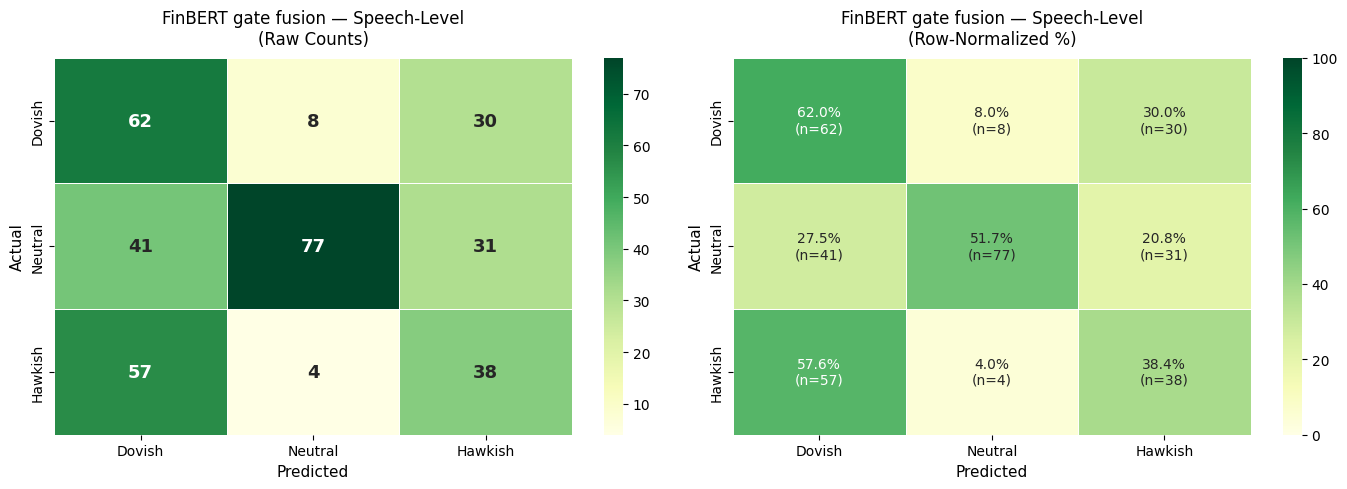

✅ Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ── Confusion Matrix — Speech-Level ──────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    # Normalize for percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    labels = ['Dovish', 'Neutral', 'Hawkish']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: Raw counts ─────────────────────────────────────────
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                ax=axes[0], cbar=True,
                annot_kws={"size": 13, "weight": "bold"})
    axes[0].set_title(f'{title}\n(Raw Counts)', fontsize=12, pad=10)
    axes[0].set_xlabel('Predicted', fontsize=11)
    axes[0].set_ylabel('Actual',    fontsize=11)

    # ── Right: Normalized % ──────────────────────────────────────
    annot_labels = np.array([
        [f"{cm_norm[i,j]:.1f}%\n(n={cm[i,j]})"
         for j in range(3)] for i in range(3)
    ])
    sns.heatmap(cm_norm, annot=annot_labels, fmt='', cmap='YlGn',
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=100,
                linewidths=0.5, linecolor='white',
                ax=axes[1], cbar=True,
                annot_kws={"size": 10})
    axes[1].set_title(f'{title}\n(Row-Normalized %)', fontsize=12, pad=10)
    axes[1].set_xlabel('Predicted', fontsize=11)
    axes[1].set_ylabel('Actual',    fontsize=11)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: confusion_matrix.png")

# ── Call karo apne best predictions pe ───────────────────────────
# Fine-tuned FinBERT (best_preds eval cell ke baad)
plot_confusion_matrix(test_labels_final, test_preds_final,
                      title="FinBERT gate fusion — Speech-Level")

# MLP pe bhi laga sakte ho:
# plot_confusion_matrix(best_mlp_true, best_mlp_preds,
#                       title="MLP on FinBERT Embeddings")

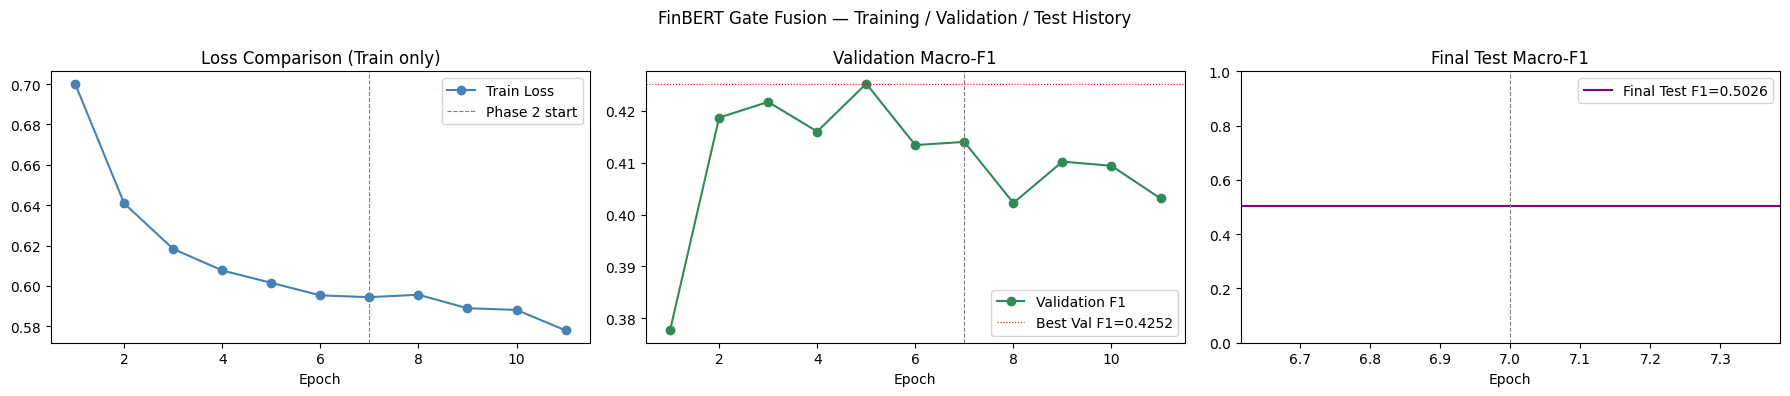

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Filter history['val_f1'] to ensure all elements are scalar numbers
# This handles cases where a tuple might have been accidentally appended
cleaned_val_f1 = [item for item in history['val_f1'] if isinstance(item, (int, float, np.number))]

# Ensure 'ep' for train_loss matches its length, assuming train_loss is consistently scalar
ep_train = range(1, len(history['train_loss']) + 1)

# Ensure 'ep_val' matches the length of the cleaned_val_f1
ep_val = range(1, len(cleaned_val_f1) + 1)

# Train Loss
axes[0].plot(ep_train, history['train_loss'], marker='o', color='steelblue', label='Train Loss')
# Removed: axes[0].plot(ep, history['test_loss'], marker='s', color='orange', label='Test Loss')
axes[0].axvline(EPOCHS, color='gray', ls='--', lw=0.8, label='Phase 2 start')
axes[0].set_title('Loss Comparison (Train only)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Validation F1
axes[1].plot(ep_val, cleaned_val_f1, marker='o', color='seagreen', label='Validation F1')
axes[1].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[1].axhline(best_f1, color='red', ls=':', lw=0.8, label=f'Best Val F1={best_f1:.4f}')
axes[1].set_title('Validation Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Test F1 (using final test_f1_final from evaluation)
# Assuming test_f1_final is available from previous cell execution
if 'test_f1_final' in globals():
    axes[2].axhline(test_f1_final, color='purple', ls='-', lw=1.5, label=f'Final Test F1={test_f1_final:.4f}')
    axes[2].set_title('Final Test Macro-F1')
else:
    axes[2].set_title('Test Macro-F1 (Data N/A)')

# Adjust axvline for test_f1 as well, using the same EPOCHS marker
axes[2].axvline(EPOCHS, color='gray', ls='--', lw=0.8)
axes[2].set_xlabel('Epoch')
# Make sure a legend is shown even if test_f1_final was not found
if 'test_f1_final' in globals():
    axes[2].legend()

plt.suptitle('FinBERT Gate Fusion — Training / Validation / Test History', fontsize=12)
plt.tight_layout()
plt.show()

## Save trained model to Google Drive
Local `best_model.pt` is lost when the Colab runtime disconnects. Run this once after training so you never have to retrain.

In [ ]:
import shutil, os
DRIVE_MODEL_PATH = '/content/drive/MyDrive/ECB/best_model.pt'
os.makedirs(os.path.dirname(DRIVE_MODEL_PATH), exist_ok=True)
shutil.copy('best_model.pt', DRIVE_MODEL_PATH)
print(f'Saved to {DRIVE_MODEL_PATH}')

Saved to /content/drive/MyDrive/ECB/best_model.pt


# RAG Pipeline — ECB Speech Tone Explorer

Query → retrieve relevant speeches (FAISS) → classify each with the trained FinBERTHybrid model → Groq LLM explains the results.

Everything below reuses objects already in memory from the pipeline above: `df`, `model`, `tokenizer`, `lm_scaler`, `temporal_scaler`, `LM_FEATURE_COLS`, `TEMPORAL_COLS`, `MultiChunkDataset`, `MAX_LEN`, `CHUNK_STRIDE`, `device`.

In [34]:
!pip install -q sentence-transformers

In [1]:
!pip install -q faiss-cpu groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 14.7 MB/s eta 0:00:00


## Step 1: Scaled LM & temporal features for the full dataset
Training only transformed the train/val/test splits. The classifier needs these for every speech we might retrieve, so we transform the whole `df` here using the *already-fitted* scalers (no re-fitting).

In [22]:
lm_feats_all       = lm_scaler.transform(df[LM_FEATURE_COLS]).astype(np.float32)
temporal_feats_all = temporal_scaler.transform(df[TEMPORAL_COLS]).astype(np.float32)
print(f'lm_feats_all: {lm_feats_all.shape}  |  temporal_feats_all: {temporal_feats_all.shape}')

lm_feats_all: (2319, 5)  |  temporal_feats_all: (2319, 3)


## Step 2: Retrieval embeddings
We reuse the **fine-tuned BERT encoder inside our trained model** (`model.bert`) for retrieval embeddings — mean-pooled over tokens (attention-masked). This is separate from the model's attention-pooled classification path and only used for similarity search.

Note: unlike classification (which chunks the full speech, no truncation), retrieval embeddings truncate at 512 tokens — standard practice for search, since we only need a representative vector, not the full text.

In [35]:
from sentence_transformers import SentenceTransformer
import re

retrieval_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_retrieval_embeddings(texts, batch_size=32):
    return retrieval_model.encode(texts, batch_size=batch_size,
                                    show_progress_bar=True,
                                    convert_to_numpy=True).astype('float32')

# Rebuild embeddings (sirf ek dafa chalana hai)
embeddings = get_retrieval_embeddings(df['contents'].astype(str).tolist())
print("Embeddings shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/73 [00:00<?, ?it/s]

Embeddings shape: (2319, 384)


In [36]:
import faiss

dimension = embeddings.shape[1]   # 384 for MiniLM (768 nahi ab)
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print(f'FAISS index rebuilt: {index.ntotal} speeches')

FAISS index rebuilt: 2319 speeches


## Step 3: Build the FAISS index

## Step 4: Retrieval function

In [37]:
def extract_year(query):
    match = re.search(r'\b(19|20)\d{2}\b', query)
    return int(match.group()) if match else None

def retrieve_speeches(query, top_k=5):
    year = extract_year(query)

    if year is not None:
        candidates = df[df['date'].dt.year == year]
        if len(candidates) == 0:
            print(f"⚠️ {year} ki koi speech nahi mili, poore dataset mein search kar rahe hain")
            candidates = df
    else:
        candidates = df

    cand_idx = candidates.index.tolist()
    cand_embeddings = embeddings[[df.index.get_loc(i) for i in cand_idx]]

    q_emb = retrieval_model.encode([query], convert_to_numpy=True).astype('float32')

    temp_index = faiss.IndexFlatL2(dimension)
    temp_index.add(cand_embeddings)
    distances, local_indices = temp_index.search(q_emb, min(top_k, len(cand_idx)))

    result_idx = [cand_idx[i] for i in local_indices[0]]
    return df.loc[result_idx].copy(), distances[0]

## Step 5: Classification function
Reuses the real `MultiChunkDataset` (no truncation, 512-token windows with 384 stride) and averages chunk logits — exactly as done in training/evaluation. Label is a required-but-unused placeholder for `MultiChunkDataset`.

In [38]:
LABELS = ['Dovish', 'Neutral', 'Hawkish']

@torch.no_grad()
def classify_speech(df_index):
    text    = str(df.loc[df_index, 'contents'])
    lm_f    = lm_feats_all[df.index.get_loc(df_index)]
    temp_f  = temporal_feats_all[df.index.get_loc(df_index)]

    ds = MultiChunkDataset([text], [0], [lm_f], [temp_f], tokenizer)
    loader = DataLoader(ds, batch_size=8, shuffle=False)

    model.eval()
    chunk_logits = []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        lm_feats       = batch['lm_features'].to(device)
        temp_feats     = batch['temporal_features'].to(device)
        with autocast(device_type=AMP_DEVICE, dtype=AMP_DTYPE):
            logits = model(input_ids, attention_mask, lm_feats, temp_feats)
        chunk_logits.append(logits.float().cpu())

    avg_logit = torch.cat(chunk_logits, dim=0).mean(dim=0)
    probs = torch.softmax(avg_logit, dim=0)
    pred  = int(torch.argmax(probs))
    return LABELS[pred], float(probs[pred])

## Step 6: Groq client
`GROQ_API_KEY` must be added under Colab's Secrets (🔑 icon in the left sidebar) with notebook access enabled.

In [39]:
from google.colab import userdata
from groq import Groq

groq_client = Groq(api_key=userdata.get('GROQ_API_KEY'))

## Step 7: End-to-end RAG query

In [40]:
def rag_query(query, top_k=5):
    results, distances = retrieve_speeches(query, top_k=top_k)

    rows = []
    for df_idx, row in results.iterrows():
        tone, confidence = classify_speech(df_idx)
        rows.append({
            'date':       str(row['date'].date()) if hasattr(row['date'], 'date') else str(row['date']),
            'speaker':    row.get('speakers', ''),
            'title':      row.get('title', ''),
            'tone':       tone,
            'confidence': round(confidence, 3),
            'excerpt':    str(row['contents'])[:400],
        })

    context = '\n\n'.join(
        f"[{r['date']}] {r['speaker']} — {r['title']}\n"
        f"Tone: {r['tone']} (confidence {r['confidence']})\n"
        f"Excerpt: {r['excerpt']}"
        for r in rows
    )

    prompt = (
        f"You are analyzing ECB (European Central Bank) speeches. "
        f"A user asked: \"{query}\"\n\n"
        f"Here are the {len(rows)} most relevant speeches retrieved, each with a tone classification "
        f"(Dovish/Neutral/Hawkish) from a trained model:\n\n{context}\n\n"
        f"Write a short, clear summary (3-5 sentences) answering the user's question based ONLY on "
        f"the speeches above. Mention the tone pattern you observe."
    )

    response = groq_client.chat.completions.create(
        model='openai/gpt-oss-safeguard-20b',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.3,
    )
    summary = response.choices[0].message.content
    return summary, rows

In [41]:
models_list_response = groq_client.models.list()
# Access the 'data' attribute, which typically contains the list of model objects
for model_item in models_list_response.data:
    print(model_item.id)

meta-llama/llama-prompt-guard-2-86m
canopylabs/orpheus-arabic-saudi
allam-2-7b
whisper-large-v3-turbo
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.8-27b
canopylabs/orpheus-v1-english
groq/compound
openai/gpt-oss-120b
openai/gpt-oss-safeguard-20b
whisper-large-v3
groq/compound-mini


In [42]:
# Quick test
summary, rows = rag_query("What was the ECB's stance on inflation in 2022?")
print(summary)
print()
for r in rows:
    print(f"- {r['date']} | {r['speaker']} | {r['tone']} ({r['confidence']})")

1 speeches → 19 chunks (avg 19.0 chunks/speech)
1 speeches → 5 chunks (avg 5.0 chunks/speech)
1 speeches → 4 chunks (avg 4.0 chunks/speech)
1 speeches → 9 chunks (avg 9.0 chunks/speech)
1 speeches → 4 chunks (avg 4.0 chunks/speech)
In 2022 the ECB largely framed inflation as a serious threat that required tightening.  Across the speeches from February, July, September and early November, the tone was consistently hawkish, stressing the need to “normalise” policy, counter supply shocks, and keep prices under control.  Only the late‑November address by Christine Lagarde carried a mild dovish note, hinting that the pace of tightening could be moderated.  Overall, the pattern shows a predominantly hawkish stance on inflation, with a brief, more cautious interjection toward the end of the year.

- 2022-11-03 |  | Hawkish (0.457)
- 2022-11-28 |  | Dovish (0.423)
- 2022-09-28 |  | Hawkish (0.532)
- 2022-02-14 |  | Hawkish (0.625)
- 2022-07-04 |  | Hawkish (0.499)


## Step 8: Gradio interface

In [43]:
!pip install -q gradio

In [44]:
import gradio as gr

def gradio_handler(query, top_k):
    summary, rows = rag_query(query, top_k=int(top_k))
    table_md = '| Date | Speaker | Tone | Confidence |\n|---|---|---|---|\n'
    for r in rows:
        table_md += f"| {r['date']} | {r['speaker']} | {r['tone']} | {r['confidence']} |\n"
    return summary, table_md

demo = gr.Interface(
    fn=gradio_handler,
    inputs=[
        gr.Textbox(label='Ask about ECB speeches', placeholder="e.g. What was the ECB's stance on inflation in 2022?"),
        gr.Slider(minimum=3, maximum=10, value=5, step=1, label='Number of speeches to retrieve'),
    ],
    outputs=[
        gr.Markdown(label='Summary'),
        gr.Markdown(label='Retrieved speeches'),
    ],
    title='ECB Speech Tone Explorer (RAG)',
    description='Retrieval-augmented exploration of ECB speeches using FinBERTHybrid v15 tone classification.',
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aeee8f26d38b7f5eec.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
